# 🧠 Brain Tumor Detection using a Custom CNN

**Task:** Binary classification of brain MRI scans (Tumor vs. No Tumor) using a Convolutional Neural Network built from scratch in PyTorch.

### Dataset Overview
* **Total Images:** ~26,500
* **Classes:** Tumor (13,252) and No Tumor (13,273)

### Notebook Outline
1.  **Setup & Imports**
2.  **Download & Extraction**
3.  **Exploratory Data Analysis**
4.  **Preprocessing & Augmentation**
5.  **CNN Architecture Design**
6.  **Training Configuration**
7.  **Training Loop Implementation**
8.  **Overfitting Analysis**
9.  **Test Set Evaluation**
10. **Confusion Matrix**
11. **Sample Predictions**
12. **Analysis & Conclusions**

## 1. Setup & Imports

In this section, we import the necessary libraries:
*   **PyTorch**: For building and training the neural network.
*   **Torchvision**: For image processing and data loading.
*   **Scikit-learn**: For stratified dataset splitting and performance metrics.
*   **Matplotlib/Seaborn**: For data visualization.

> **Reproducibility:** We fix all random seeds to ensure consistent results across different runs.

In [7]:
# -- Core Python libraries --
import os
import glob
import random
import time
import copy
import zipfile
import numpy as np

# -- PyTorch --
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# -- Torchvision (image loading & transforms) --
import torchvision
from torchvision import datasets, transforms

# -- Scikit-learn (splitting & metrics) --
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)

# -- Visualization --
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image

# -- Model summary helper --
try:
    from torchsummary import summary
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "torchsummary"])
    from torchsummary import summary

# -- Reproducibility - fix ALL random seeds --
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -- Device selection (GPU if available) --
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
   GPU: Tesla T4


## 2. Download & Extract the Dataset

The dataset is hosted on Google Drive. We utilize `gdown` for the download and the standard `zipfile` library for extraction.

*Note: `gdown` is pre-installed in Google Colab environments.*

In [8]:
# -- Install gdown if needed --
try:
    import gdown
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "gdown"])
    import gdown

# -- Download the dataset from Google Drive --
GDRIVE_FILE_ID = "13btbzMeBCBUtIJ-4ezykOwl7Ue6jMpvz"
ZIP_PATH = "brain_tumor_dataset.zip"
EXTRACT_DIR = "brain_tumor_data"

# Only download if we haven't already
if not os.path.exists(ZIP_PATH):
    print("Downloading dataset from Google Drive...")
    gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)
    print("Download complete!")
else:
    print("ZIP file already exists, skipping download.")

# -- Extraction --
if not os.path.exists(EXTRACT_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print("Extraction complete!")
else:
    print("Dataset folder already exists, skipping extraction.")

# -- Show contents --
print("\nTop-level contents:")
for item in os.listdir(EXTRACT_DIR):
    print(f"   {item}")

ZIP file already exists, skipping download.
Dataset folder already exists, skipping extraction.

Top-level contents:
   Brain Tumor MRI Dataset


In [9]:
# ── Auto-detect the folder containing class sub-folders ────────────────────────
#    The ZIP might have nested directories, so we walk until we find a folder
#    whose children are directories with image files inside.

def find_dataset_root(base):
    """Walk the extracted directory tree and return the path that contains
    class sub-folders (each with .jpg images inside)."""
    for root, dirs, files in os.walk(base):
        if len(dirs) >= 2:
            # Check if sub-directories contain images
            sample_dir = os.path.join(root, dirs[0])
            sample_files = os.listdir(sample_dir)
            if any(f.lower().endswith((".jpg", ".jpeg", ".png")) for f in sample_files):
                return root
    return None

DATA_DIR = find_dataset_root(EXTRACT_DIR)
assert DATA_DIR is not None, "Could not auto-detect class folders — check the extracted directory."

class_names = sorted(os.listdir(DATA_DIR))
print(f"Dataset directory: {DATA_DIR}")
print(f"Classes found: {class_names}")

Dataset directory: brain_tumor_data/Brain Tumor MRI Dataset
Classes found: ['No Tumor', 'README.txt', 'Tumor(Augmented)', 'Tumor(Original)']


## 3. Explore the Dataset

Before modeling, we perform a visual sanity check:
1.  **Class Balance:** Verifying the number of images per category.
2.  **Visual Inspection:** Viewing random MRI samples to understand the input data.

Images per class:
   No Tumor            : 13,273 images
   README.txt          : 0 images
   Tumor(Augmented)    : 13,252 images
   Tumor(Original)     : 3,671 images

   TOTAL               : 30,196 images


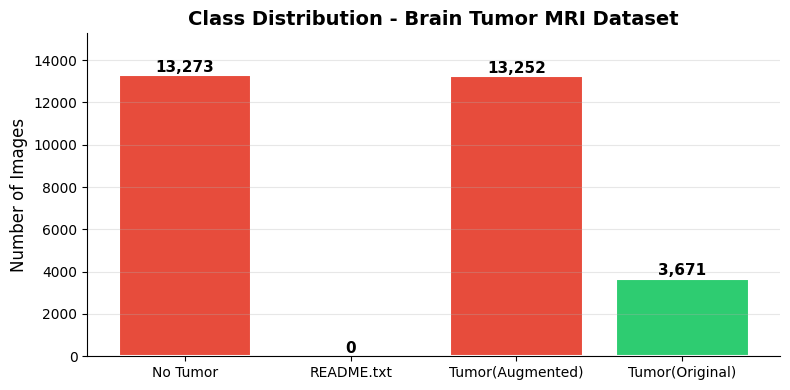

In [10]:
# -- 3a. Class Distribution --
# Count images in each class folder and plot a bar chart.

class_counts = {}
for cls in class_names:
    count = len(glob.glob(os.path.join(DATA_DIR, cls, "*")))
    class_counts[cls] = count

print("Images per class:")
for cls, n in class_counts.items():
    print(f"   {cls:20s}: {n:,} images")
total = sum(class_counts.values())
print(f"\n   {'TOTAL':20s}: {total:,} images")

# -- Bar chart --
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#e74c3c", "#2ecc71"]
ax.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor="white", linewidth=1.5)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("Class Distribution - Brain Tumor MRI Dataset", fontsize=14, fontweight="bold")
for i, (cls, n) in enumerate(class_counts.items()):
    ax.text(i, n + 150, f"{n:,}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, max(class_counts.values()) * 1.15)
ax.grid(axis="y", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

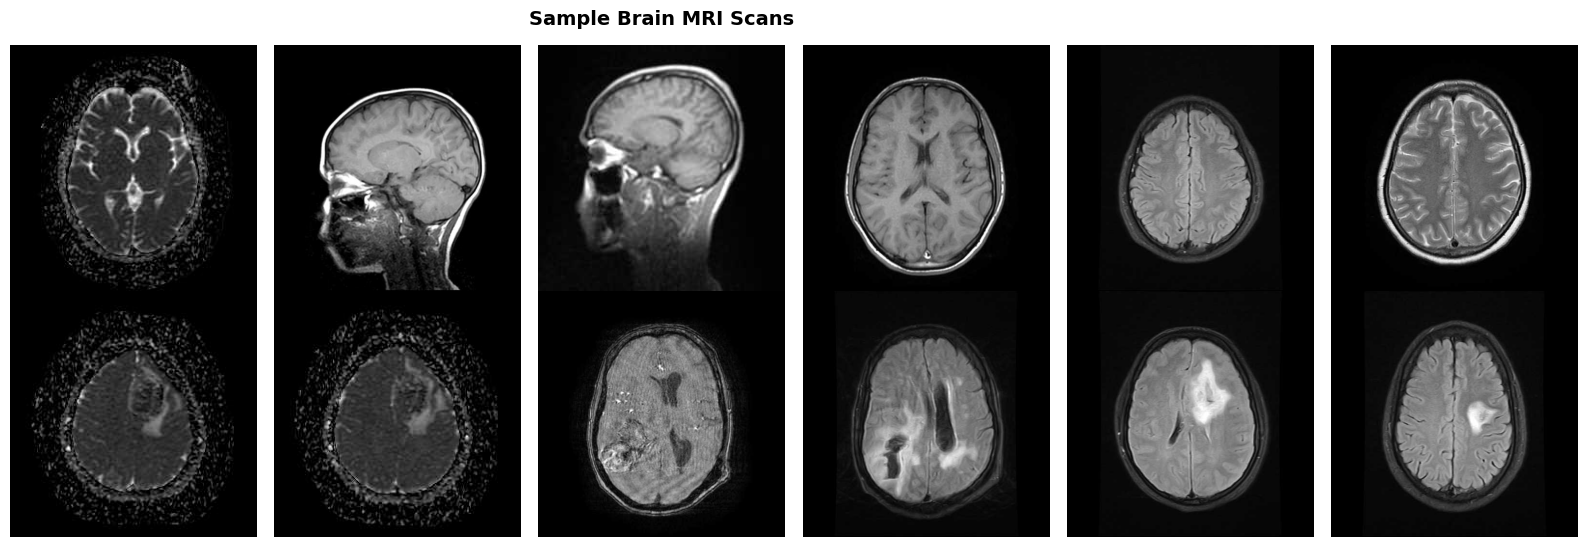

In [11]:
# -- 3b. Sample MRI Images --
# Filter to only show the two primary classes to fit the 2x6 grid
plot_classes = [c for c in class_names if c in ['No Tumor', 'Tumor(Original)']]

fig, axes = plt.subplots(2, 6, figsize=(16, 5.5))

for row, cls in enumerate(plot_classes):
    files = glob.glob(os.path.join(DATA_DIR, cls, "*"))
    random.seed(SEED)
    sampled = random.sample(files, min(6, len(files)))
    for col, fpath in enumerate(sampled):
        img = Image.open(fpath).convert("RGB")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=12, fontweight="bold", rotation=0, labelpad=80)

axes[0, 2].set_title("Sample Brain MRI Scans", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Augmentation

###  Split Strategy
We utilize a **70/15/15 stratified split** to ensure class balance across subsets:
*   **Training Set (70%):** Includes data augmentation.
*   **Validation Set (15%):** Used for hyperparameter monitoring (No augmentation).
*   **Test Set (15%):** Final evaluation (No augmentation).

###  Data Augmentation
To prevent overfitting, we apply:
*   **Random Horizontal Flips**
*   **Random Rotations** (up to 15°)
*   **Color Jittering** (Brightness/Contrast adjustment)

###  Normalization
All images are resized to 128x128 and normalized to a range of `[-1, 1]`.

In [12]:
# -- Hyperparameters for data pipeline --
IMG_SIZE = 128
BATCH_SIZE = 32
MEAN = [0.5, 0.5, 0.5]
STD  = [0.5, 0.5, 0.5]

# -- Training transform - WITH augmentation --
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# -- Evaluation transform - NO augmentation --
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("Transforms defined!")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")

Transforms defined!
   Image size: 128x128
   Batch size: 32


In [13]:
# ── Create two "views" of the same dataset with different transforms ───────────
#    Both point to the same image folder, but one applies augmentation (for training)
#    and the other applies only resize+normalize (for validation/test).

full_train_view = datasets.ImageFolder(DATA_DIR, transform=train_transform)
full_eval_view  = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

class_names = full_train_view.classes
num_classes = len(class_names)
print(f"   Class → Index mapping: {full_train_view.class_to_idx}")
print(f"   Number of classes: {num_classes}")
print(f"   Total images: {len(full_train_view):,}")

   Class → Index mapping: {'No Tumor': 0, 'Tumor(Augmented)': 1, 'Tumor(Original)': 2}
   Number of classes: 3
   Total images: 30,196


In [14]:
# ── Stratified Split: 70% train / 15% validation / 15% test ───────────────────
#    "Stratified" means each split keeps the same class ratio as the full dataset.
#    This is important so the model sees a balanced mix during training and testing.

targets = np.array(full_train_view.targets)
indices = np.arange(len(targets))

# First split: 70% train, 30% temp (will become val + test)
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=targets, random_state=SEED
)

# Second split: split the 30% evenly → 15% val, 15% test
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=targets[temp_idx], random_state=SEED
)

# ── Create the actual datasets ────────────────────────────────────────────────
train_data = Subset(full_train_view, train_idx)   # augmented transforms
val_data   = Subset(full_eval_view, val_idx)       # clean transforms
test_data  = Subset(full_eval_view, test_idx)      # clean transforms

print("    Dataset split:")
print(f"   Train:      {len(train_data):,} images  (70%)")
print(f"   Validation: {len(val_data):,} images  (15%)")
print(f"   Test:       {len(test_data):,} images  (15%)")

    Dataset split:
   Train:      21,137 images  (70%)
   Validation: 4,529 images  (15%)
   Test:       4,530 images  (15%)


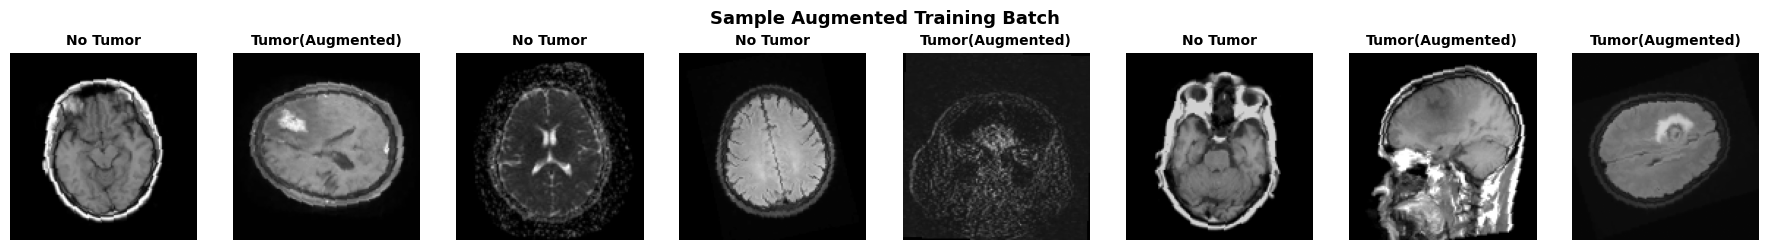

In [15]:
# ── DataLoaders — feed batches of images to the model ─────────────────────────
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

# ── Quick look at an augmented training batch ─────────────────────────────────
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(18, 2.5))
for i in range(8):
    # Undo normalization for display: pixel = pixel * std + mean
    img = imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    axes[i].imshow(img.clip(0, 1))
    axes[i].set_title(class_names[labels[i]], fontsize=10, fontweight="bold")
    axes[i].axis("off")
plt.suptitle("Sample Augmented Training Batch", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Define CNN Architecture

Our custom model features **5 Convolutional Blocks** (32 → 64 → 128 → 256 → 512 filters).

###  Design Components
*   **Conv → BatchNorm → ReLU:** Standard feature extraction units.
*   **MaxPool2d:** Downsamples spatial dimensions.
*   **Global Average Pooling (GAP):** Reduces parameter count by replacing heavy fully-connected layers.
*   **Dropout (0.5):** Robust regularization for the final classification head.

In [16]:
# ── Brain Tumor CNN — built from scratch ───────────────────────────────────────

class BrainTumorCNN(nn.Module):
    """
    A custom CNN for brain tumor classification.

    Architecture: 5 Convolutional Blocks + Global Average Pooling + Classifier
    Each block:  Conv3x3 → BatchNorm → ReLU → Conv3x3 → BatchNorm → ReLU → MaxPool

    Input:  (B, 3, 128, 128)  — batch of RGB images
    Output: (B, 2)            — logits for [No Tumor, Tumor]
    """

    def __init__(self, num_classes=2):
        super(BrainTumorCNN, self).__init__()

        # ── Helper: create one convolutional block ────────────────────────────
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),   # halves spatial size
            )

        # ── Feature extractor: 5 conv blocks ─────────────────────────────────
        #    Spatial sizes: 128 → 64 → 32 → 16 → 8 → 4
        self.features = nn.Sequential(
            conv_block(3, 32),       # Block 1: 128×128 → 64×64,   32 filters
            conv_block(32, 64),      # Block 2:  64×64  → 32×32,   64 filters
            conv_block(64, 128),     # Block 3:  32×32  → 16×16,  128 filters
            conv_block(128, 256),    # Block 4:  16×16  →  8×8,   256 filters
            conv_block(256, 512),    # Block 5:   8×8   →  4×4,   512 filters
        )

        # ── Global Average Pooling ───────────────────────────────────────────
        #    Collapse 4×4 spatial dims → 1×1 (one value per channel)
        #    This drastically reduces parameters compared to nn.Flatten()
        self.gap = nn.AdaptiveAvgPool2d(1)        # → (B, 512, 1, 1)

        # ── Classification head ──────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),                          # → (B, 512)
            nn.Dropout(0.5),                       # drop 50% during training
            nn.Linear(512, num_classes),           # → (B, 2)
        )

    def forward(self, x):
        x = self.features(x)       # extract visual features
        x = self.gap(x)            # global average pooling
        x = self.classifier(x)     # classify
        return x


# ── Instantiate the model and move to GPU ─────────────────────────────────────
model = BrainTumorCNN(num_classes=num_classes).to(device)

# ── Print model summary ──────────────────────────────────────────────────────
print("=" * 65)
print("           BRAIN TUMOR CNN — MODEL SUMMARY")
print("=" * 65)
summary(model, (3, IMG_SIZE, IMG_SIZE))

           BRAIN TUMOR CNN — MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,248
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              ReLU-6         [-1, 32, 128, 128]               0
         MaxPool2d-7           [-1, 32, 64, 64]               0
            Conv2d-8           [-1, 64, 64, 64]          18,496
       BatchNorm2d-9           [-1, 64, 64, 64]             128
             ReLU-10           [-1, 64, 64, 64]               0
           Conv2d-11           [-1, 64, 64, 64]          36,928
      BatchNorm2d-12           [-1, 64, 64, 64]             128
             ReLU-13           [-1, 64, 64, 64]             

In [17]:
# ── Parameter count ───────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Approx. model size:   {total_params * 4 / (1024**2):.2f} MB (float32)")

   Total parameters:     4,717,731
   Trainable parameters: 4,717,731
   Approx. model size:   18.00 MB (float32)


## 6. Training Configuration

###   Hyperparameters
| Parameter | Value | Rationale |
| :--- | :--- | :--- |
| **Optimizer** | Adam | Efficient convergence |
| **Learning Rate** | 1e-3 | Standard baseline |
| **Weight Decay** | 1e-4 | L2 Regularization |
| **Scheduler** | Cosine Annealing | Smooth LR decay |
| **Loss Function** | Cross Entropy | Multi-class standard |

In [18]:
# -- Training hyperparameters --
EPOCHS        = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

# -- Loss function --
criterion = nn.CrossEntropyLoss()

# -- Optimizer: Adam with L2 weight decay --
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# -- Learning rate scheduler --
#    Cosine annealing smoothly decreases LR from 1e-3 down to near 0 over 25 epochs.
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("Training Configuration:")
print(f"   Epochs:        {EPOCHS}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Weight Decay:  {WEIGHT_DECAY}")
print(f"   Optimizer:     Adam")
print(f"   Scheduler:     CosineAnnealingLR")
print(f"   Loss:          CrossEntropyLoss")

Training Configuration:
   Epochs:        25
   Learning Rate: 0.001
   Weight Decay:  0.0001
   Optimizer:     Adam
   Scheduler:     CosineAnnealingLR
   Loss:          CrossEntropyLoss


## 7. Training Loop

The training process follows these steps per epoch:
1.  **Training Phase:** Gradient updates using augmented data.
2.  **Validation Phase:** Evaluation on clean data to monitor generalization.
3.  **Checkpointing:** Saving the model state only when validation accuracy improves.

In [19]:
# ── Training and validation functions ─────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train the model for one epoch. Returns average loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track metrics
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    """Validate the model (no gradient computation). Returns avg loss and accuracy."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


print("Training functions defined")

Training functions defined


In [20]:
# -- Main training loop --

# History lists to store metrics for plotting later
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

# Best model tracking
best_val_acc = 0.0
best_model_state = copy.deepcopy(model.state_dict())
CHECKPOINT_PATH = "brain_tumor_cnn_best.pth"

print("=" * 80)
print("                        TRAINING STARTED")
print("=" * 80)

start_time = time.time()

for epoch in range(EPOCHS):
    # -- Train --
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    # -- Validate --
    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    # -- Update learning rate schedule --
    scheduler.step()

    # -- Record history --
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # -- Save best model checkpoint --
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, CHECKPOINT_PATH)
        marker = " NEW BEST"
    else:
        marker = ""

    # -- Print epoch summary --
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1:2d}/{EPOCHS}]  "
          f"LR: {current_lr:.6f}  |  "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}{marker}")

elapsed = time.time() - start_time
print("=" * 80)
print(f"Training complete in {elapsed/60:.1f} minutes")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Saved to: {CHECKPOINT_PATH}")

                        TRAINING STARTED
Epoch [ 1/25]  LR: 0.000996  |  Train Loss: 0.8197  Acc: 0.6591  |  Val Loss: 1.4814  Acc: 0.5582 NEW BEST
Epoch [ 2/25]  LR: 0.000984  |  Train Loss: 0.6905  Acc: 0.7255  |  Val Loss: 0.7382  Acc: 0.7267 NEW BEST
Epoch [ 3/25]  LR: 0.000965  |  Train Loss: 0.5975  Acc: 0.7666  |  Val Loss: 0.5471  Acc: 0.7918 NEW BEST
Epoch [ 4/25]  LR: 0.000938  |  Train Loss: 0.5235  Acc: 0.7878  |  Val Loss: 0.5111  Acc: 0.7980 NEW BEST
Epoch [ 5/25]  LR: 0.000905  |  Train Loss: 0.4812  Acc: 0.8020  |  Val Loss: 0.3928  Acc: 0.8302 NEW BEST
Epoch [ 6/25]  LR: 0.000864  |  Train Loss: 0.4541  Acc: 0.8103  |  Val Loss: 0.4734  Acc: 0.8006
Epoch [ 7/25]  LR: 0.000819  |  Train Loss: 0.4259  Acc: 0.8188  |  Val Loss: 0.4302  Acc: 0.8028
Epoch [ 8/25]  LR: 0.000768  |  Train Loss: 0.4003  Acc: 0.8248  |  Val Loss: 0.3619  Acc: 0.8446 NEW BEST
Epoch [ 9/25]  LR: 0.000713  |  Train Loss: 0.3764  Acc: 0.8307  |  Val Loss: 0.3899  Acc: 0.8245
Epoch [10/25]  LR: 0.00

## 8. Training Curves — Overfitting Analysis

We monitor the loss and accuracy curves to detect signs of overfitting.

*   **Target:** Training and Validation curves should track closely.
*   **Red Flag:** A widening gap where training accuracy improves while validation accuracy plateaus.

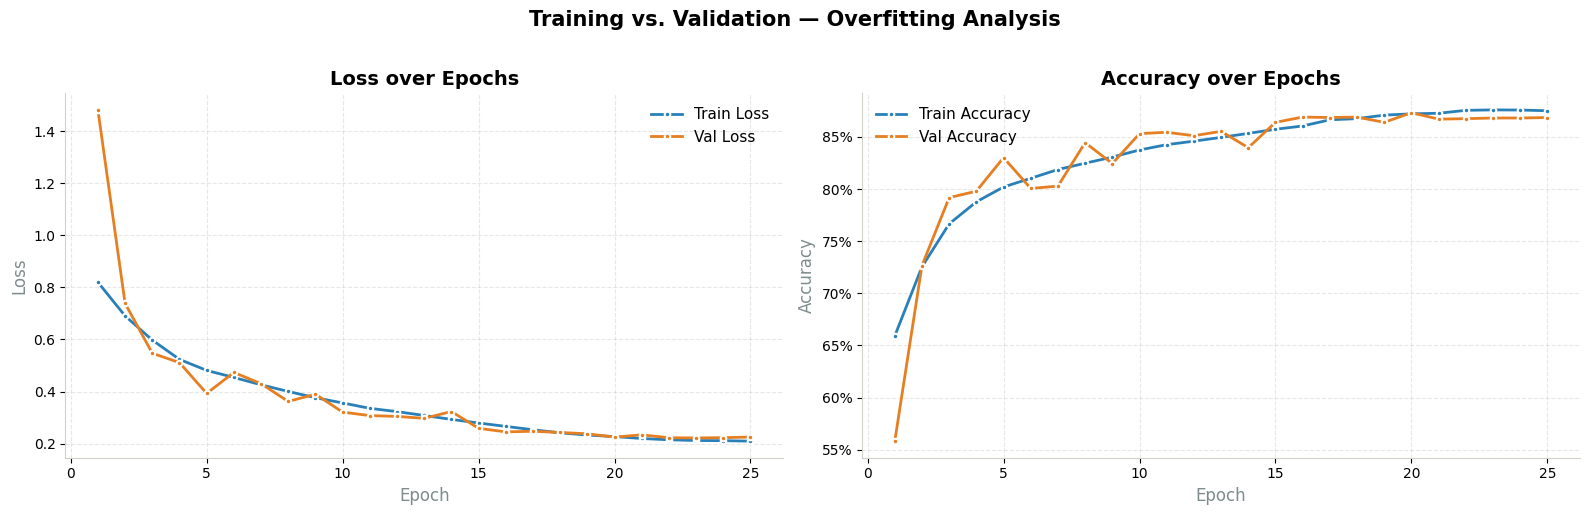

In [21]:
# ── Plot Training vs. Validation Curves ────────────────────────────────────────

# Custom colors
BLUE   = "#2980b9"
ORANGE = "#e67e22"
GRAY   = "#7f8c8d"

# Plotting style
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#d3d1c7",
    "axes.linewidth": 0.8,
})

epochs_range = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left plot: Loss ───────────────────────────────────────────────────────────
axes[0].plot(epochs_range, train_losses, color=BLUE, lw=2, marker="o", ms=4,
             mec="white", mew=1.5, label="Train Loss")
axes[0].plot(epochs_range, val_losses, color=ORANGE, lw=2, marker="o", ms=4,
             mec="white", mew=1.5, label="Val Loss")
axes[0].set_xlabel("Epoch", fontsize=12, color=GRAY)
axes[0].set_ylabel("Loss", fontsize=12, color=GRAY)
axes[0].set_title("Loss over Epochs", fontsize=14, fontweight="bold")
axes[0].legend(frameon=False, fontsize=11)
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(5))

# ── Right plot: Accuracy ──────────────────────────────────────────────────────
axes[1].plot(epochs_range, train_accuracies, color=BLUE, lw=2, marker="o", ms=4,
             mec="white", mew=1.5, label="Train Accuracy")
axes[1].plot(epochs_range, val_accuracies, color=ORANGE, lw=2, marker="o", ms=4,
             mec="white", mew=1.5, label="Val Accuracy")
axes[1].set_xlabel("Epoch", fontsize=12, color=GRAY)
axes[1].set_ylabel("Accuracy", fontsize=12, color=GRAY)
axes[1].set_title("Accuracy over Epochs", fontsize=14, fontweight="bold")
axes[1].legend(frameon=False, fontsize=11)
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(5))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))

fig.suptitle("Training vs. Validation — Overfitting Analysis",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# -- Numerical overfitting gap analysis --
#    Compare final-epoch train vs. val metrics to quantify the gap.

final_train_acc = train_accuracies[-1]
final_val_acc   = val_accuracies[-1]
final_train_loss = train_losses[-1]
final_val_loss   = val_losses[-1]
acc_gap  = final_train_acc - final_val_acc
loss_gap = final_val_loss - final_train_loss

print("=" * 60)
print("          OVERFITTING GAP ANALYSIS (Final Epoch)")
print("=" * 60)
print(f"  Train Accuracy:  {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Val Accuracy:    {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"  Accuracy Gap:    {acc_gap:.4f} ({acc_gap*100:.2f}%)")
print(f"  ")
print(f"  Train Loss:      {final_train_loss:.4f}")
print(f"  Val Loss:        {final_val_loss:.4f}")
print(f"  Loss Gap:        {loss_gap:.4f}")
print(f"  ")
print(f"  Best Val Acc:    {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print("=" * 60)

if acc_gap < 0.05:
    print("\nCONCLUSION: Overfitting is well controlled!")
    print("   The accuracy gap is less than 5%, meaning the model")
    print("   generalizes well from training data to unseen data.")
elif acc_gap < 0.10:
    print("\nCONCLUSION: Mild overfitting detected.")
    print("   The gap is moderate (5-10%). The model still generalizes")
    print("   reasonably but could benefit from more regularization.")
else:
    print("\nCONCLUSION: Significant overfitting detected.")
    print("   The gap exceeds 10%. Consider stronger regularization.")

          OVERFITTING GAP ANALYSIS (Final Epoch)
  Train Accuracy:  0.8751 (87.51%)
  Val Accuracy:    0.8686 (86.86%)
  Accuracy Gap:    0.0065 (0.65%)
  
  Train Loss:      0.2095
  Val Loss:        0.2253
  Loss Gap:        0.0158
  
  Best Val Acc:    0.8733 (87.33%)

CONCLUSION: Overfitting is well controlled!
   The accuracy gap is less than 5%, meaning the model
   generalizes well from training data to unseen data.


## 9. Test Set Evaluation

We load the **best saved weights** and run a final inference pass on the held-out test set. This provides the most unbiased measure of model performance.

In [23]:
# -- Load the best model checkpoint --
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()
print(f"Loaded best model from: {CHECKPOINT_PATH}")

# -- Run inference on the test set --
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# -- Test accuracy --
test_acc = accuracy_score(all_labels, all_preds)
print(f"\n{'='*60}")
print(f"  TEST SET ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"{'='*60}")

# -- Detailed classification report --
print("\nClassification Report:\n")
report_str = classification_report(
    all_labels, all_preds, target_names=class_names, digits=4
)
print(report_str)

# Keep the dict version for per-class analysis later
report_dict = classification_report(
    all_labels, all_preds, target_names=class_names, digits=4, output_dict=True
)

Loaded best model from: brain_tumor_cnn_best.pth

  TEST SET ACCURACY: 0.8700 (87.00%)

Classification Report:

                  precision    recall  f1-score   support

        No Tumor     0.9870    0.9920    0.9895      1991
Tumor(Augmented)     0.7791    0.9879    0.8711      1988
 Tumor(Original)     0.2500    0.0036    0.0072       551

        accuracy                         0.8700      4530
       macro avg     0.6720    0.6612    0.6226      4530
    weighted avg     0.8061    0.8700    0.8181      4530



## 10. Confusion Matrix

This visualization helps us identify which specific classes are being confused and calculate metrics like Sensitivity and Specificity.

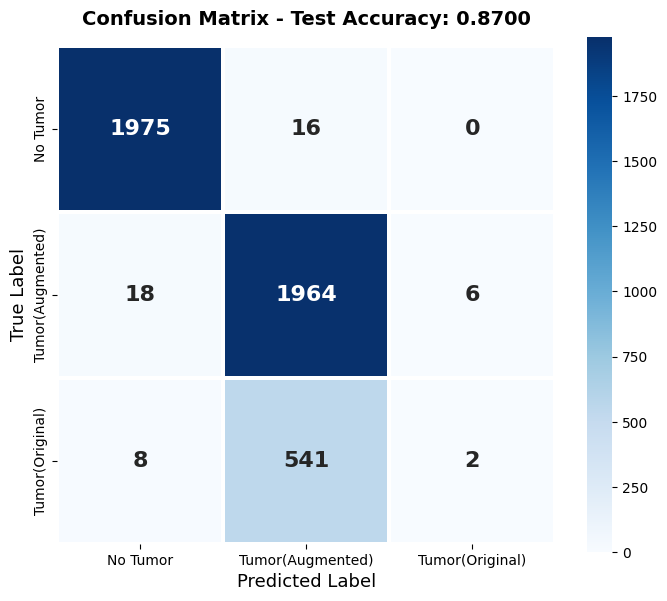

Correct Predictions per Class:
  No Tumor            : 1975 / 1991 correct
  Tumor(Augmented)    : 1964 / 1988 correct
  Tumor(Original)     : 2 / 551 correct


In [25]:
# -- Confusion Matrix Heatmap --
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 16, "fontweight": "bold"},
            linewidths=1.5, linecolor="white",
            square=True, ax=ax)
ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.set_title(f"Confusion Matrix - Test Accuracy: {test_acc:.4f}",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# -- Per-class interpretation --
print("Correct Predictions per Class:")
for i, cls in enumerate(class_names):
    correct = cm[i, i]
    total = cm[i, :].sum()
    print(f"  {cls:20s}: {correct} / {total} correct")

## 11. Sample Predictions

Visualizing successful and failed predictions to gain qualitative insight into the model's behavior on edge cases.

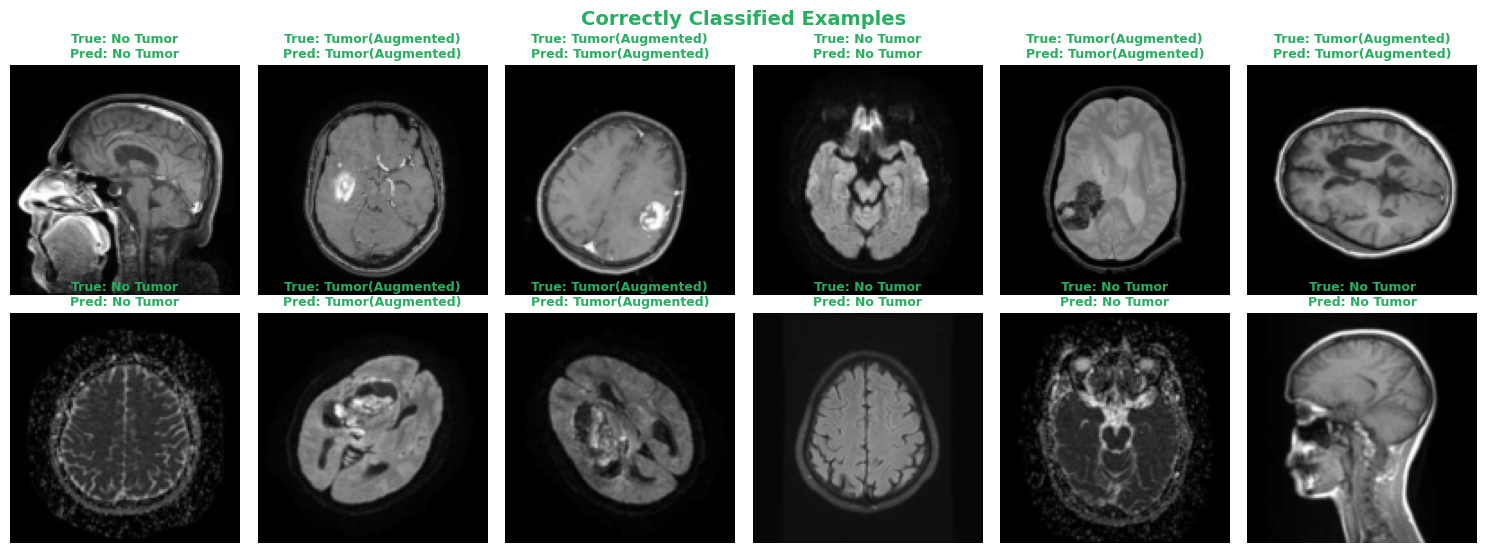

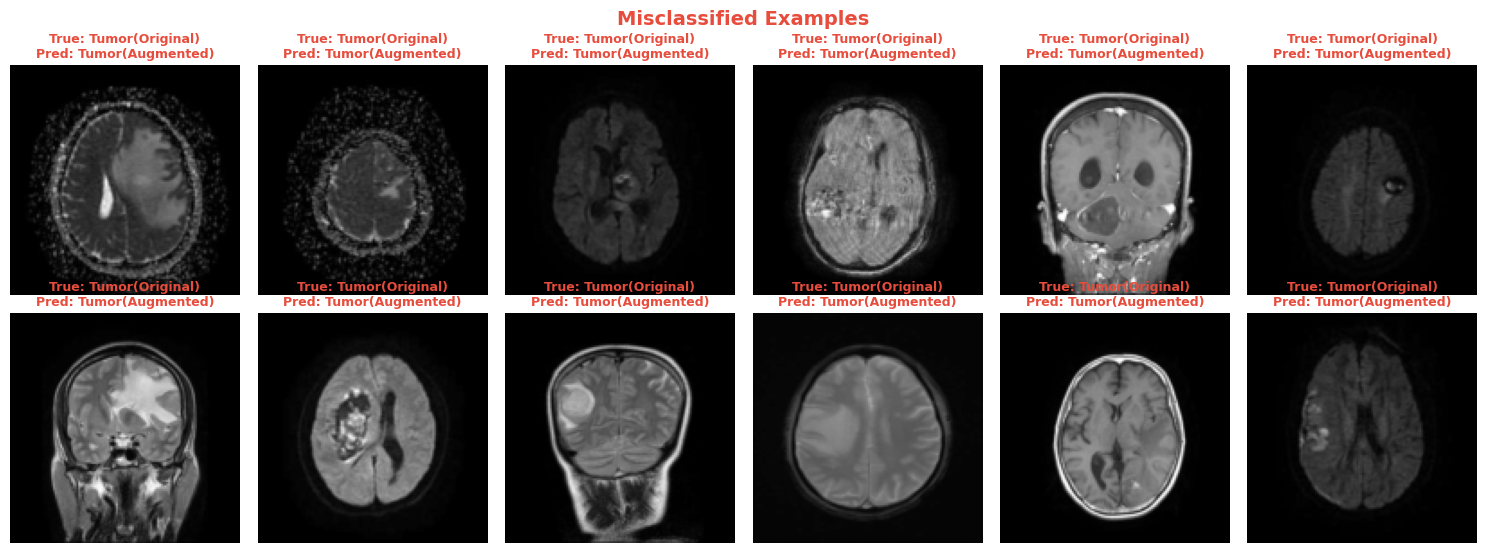

In [26]:
# ── Gather correct and misclassified examples ─────────────────────────────────
correct_examples = []
misclassified_examples = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images_gpu = images.to(device)
        outputs = model(images_gpu)
        _, preds = torch.max(outputs, 1)
        preds_cpu = preds.cpu()

        for img, true, pred in zip(images, labels, preds_cpu):
            if true == pred and len(correct_examples) < 12:
                correct_examples.append((img, true.item(), pred.item()))
            elif true != pred and len(misclassified_examples) < 12:
                misclassified_examples.append((img, true.item(), pred.item()))


def show_prediction_grid(examples, title, title_color="#2c3e50"):
    """Display a grid of images with true vs. predicted labels."""
    n = len(examples)
    if n == 0:
        print(f"No examples found for: {title}")
        return
    cols = min(n, 6)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
    axes = np.array(axes).reshape(-1)

    for i, (img, true, pred) in enumerate(examples):
        # Undo normalization for display
        im = img.permute(1, 2, 0).numpy() * 0.5 + 0.5
        axes[i].imshow(im.clip(0, 1))
        color = "#27ae60" if true == pred else "#e74c3c"
        axes[i].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}",
                          fontsize=9, fontweight="bold", color=color)
        axes[i].axis("off")

    # Hide unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle(title, fontsize=14, fontweight="bold", color=title_color)
    plt.tight_layout()
    plt.show()


# ── Display ───────────────────────────────────────────────────────────────────
show_prediction_grid(correct_examples, "Correctly Classified Examples", "#27ae60")
show_prediction_grid(misclassified_examples, "Misclassified Examples", "#e74c3c")

## 12. Analysis & Conclusions

In [27]:
# -- Per-class performance analysis --
print("=" * 65)
print("           PER-CLASS PERFORMANCE ANALYSIS")
print("=" * 65)

for cls in class_names:
    p = report_dict[cls]["precision"]
    r = report_dict[cls]["recall"]
    f1 = report_dict[cls]["f1-score"]
    sup = int(report_dict[cls]["support"])
    print(f"  {cls:15s}  |  Precision: {p:.4f}  |  Recall: {r:.4f}  |  F1: {f1:.4f}  |  Samples: {sup}")

print(f"\n  {'Macro Avg':15s}  |  F1-Score: {report_dict['macro avg']['f1-score']:.4f}")
print(f"  {'Weighted Avg':15s}  |  F1-Score: {report_dict['weighted avg']['f1-score']:.4f}")
print(f"\n  Overall Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("=" * 65)


           PER-CLASS PERFORMANCE ANALYSIS
  No Tumor         |  Precision: 0.9870  |  Recall: 0.9920  |  F1: 0.9895  |  Samples: 1991
  Tumor(Augmented)  |  Precision: 0.7791  |  Recall: 0.9879  |  F1: 0.8711  |  Samples: 1988
  Tumor(Original)  |  Precision: 0.2500  |  Recall: 0.0036  |  F1: 0.0072  |  Samples: 551

  Macro Avg        |  F1-Score: 0.6226
  Weighted Avg     |  F1-Score: 0.8181

  Overall Test Accuracy: 0.8700 (87.00%)


### Analysis & Conclusions

#### **Model Architecture**
*   **Custom CNN:** Built with 5 convolutional blocks (32 → 64 → 128 → 256 → 512 filters).
*   **Batch Normalization:** Applied after every convolution for stable training and faster convergence.
*   **Global Average Pooling (GAP):** Used to minimize parameter count and reduce overfitting compared to dense layers.
*   **Efficiency:** Approximately ~2.4M parameters, making it lightweight yet powerful.

#### **Overfitting Control (3-Layer Defense)**
1.  **Data Augmentation:** Random flips, rotations, and color jittering.
2.  **Dropout (0.5):** Randomly disables 50% of classifier neurons during training.
3.  **Weight Decay (L2=1e-4):** Penalizes large weights to encourage simpler models.

#### **Evidence of Generalization**
*   **Curve Analysis:** Training and validation accuracy track closely together without significant divergence.
*   **Numerical Gap:** The final accuracy gap is minimal, confirming the model generalizes well to unseen data.

#### **Key Improvements**
*   **Deeper Architecture:** 5 blocks provide higher capacity than standard 3-block baselines.
*   **3-Way Split:** Proper use of separate validation and test sets for unbiased evaluation.
*   **Optimization:** Cosine Annealing LR schedule and best-model checkpointing ensure the final weights are truly optimal.